# <span style="font-family:serif; font-size:28px;"> Content</span>

1. Introduction
    * What is Customer Churn?
    * How can customer churn be reducded?
    * Objectives
2. Loading libraries and data
3. Undertanding the data
4. Missing Value Analysis
5. Data Visualization
    * Demographics
    * Services
    * Account information
6. Data Preprocessing
   * Select Numerical and Categorical Variables
   * Define Features and Target
   * Split the Dataset
   * Create Preprocessing Pipelines
   * Combine Pipelines with ColumnTransformer
7. Machine Learning Model Selection
   * Stratified K-Fold Cross Validation
   * Model Comparison
   * Hyperparameter Tuning
   * Final Model Selection
8. Model Evaluation and Predictions
   * Model Evaluation
   * Threshold Adjustment
   * ROC Curve
   * Precision-Recall Curve
   * Feature Importance
9. Further Business Implications

# <span style="font-family:serif; font-size:28px;">Customer Churn Prediction</span>

# <span style="font-family:serif; font-size:28px;"> 1. Introduction</span>

**What is customer churn?**

Customer churn refers to customers who stop using a company’s products or services over a period of time. It is an important metric because losing customers can reduce revenue and affect business growth.

**How Can Customer Churn Be Reduced?**

Customer churn can be reduced by improving customer satisfaction, providing better support, offering personalized services, and identifying customers at risk of leaving. Companies often use data analysis and machine learning to detect churn patterns and improve customer retention.

**Objectives**

This notebook explores customer churn data to identify patterns and insights related to customer behavior and business performance. Some of the main questions analyzed include:

- What percentage of customers have churned compared to active customers?
- Are there churn patterns related to gender?
- Does the type of service influence customer churn?
- Which services generate the highest revenue?
- Which customer features are most related to profitability and retention?
- What additional insights can be discovered through exploratory data analysis?

# <span style="font-family:serif; font-size:28px;">2. Loading libraries and data</span>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import missingno as msno
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay,
    roc_curve,
    auc
)

In [ ]:
# Install dependency
!pip install kagglehub[pandas-datasets]

import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "blastchar/telco-customer-churn",
    "WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

/tmp/ipykernel_3451/4134852458.py:7: DeprecationWarning:

Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.



Using Colab cache for faster access to the 'telco-customer-churn' dataset.


# <span style="font-family:serif; font-size:28px;">3. Understanding the data</span>

Each row represents a customer, each column contains customer’s attributes described on the column Metadata.

This data set includes information about:

- Customers who left within the last month – the column is called Churn
- Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
- Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
- Demographic info about customers – gender, and if they have partners and dependents


In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


The target the we will use to guide the exploration is Churn.

# <span style="font-family:serif; font-size:28px;">4. Missing Value Analysis</span>

<Figure size 1200x600 with 0 Axes>

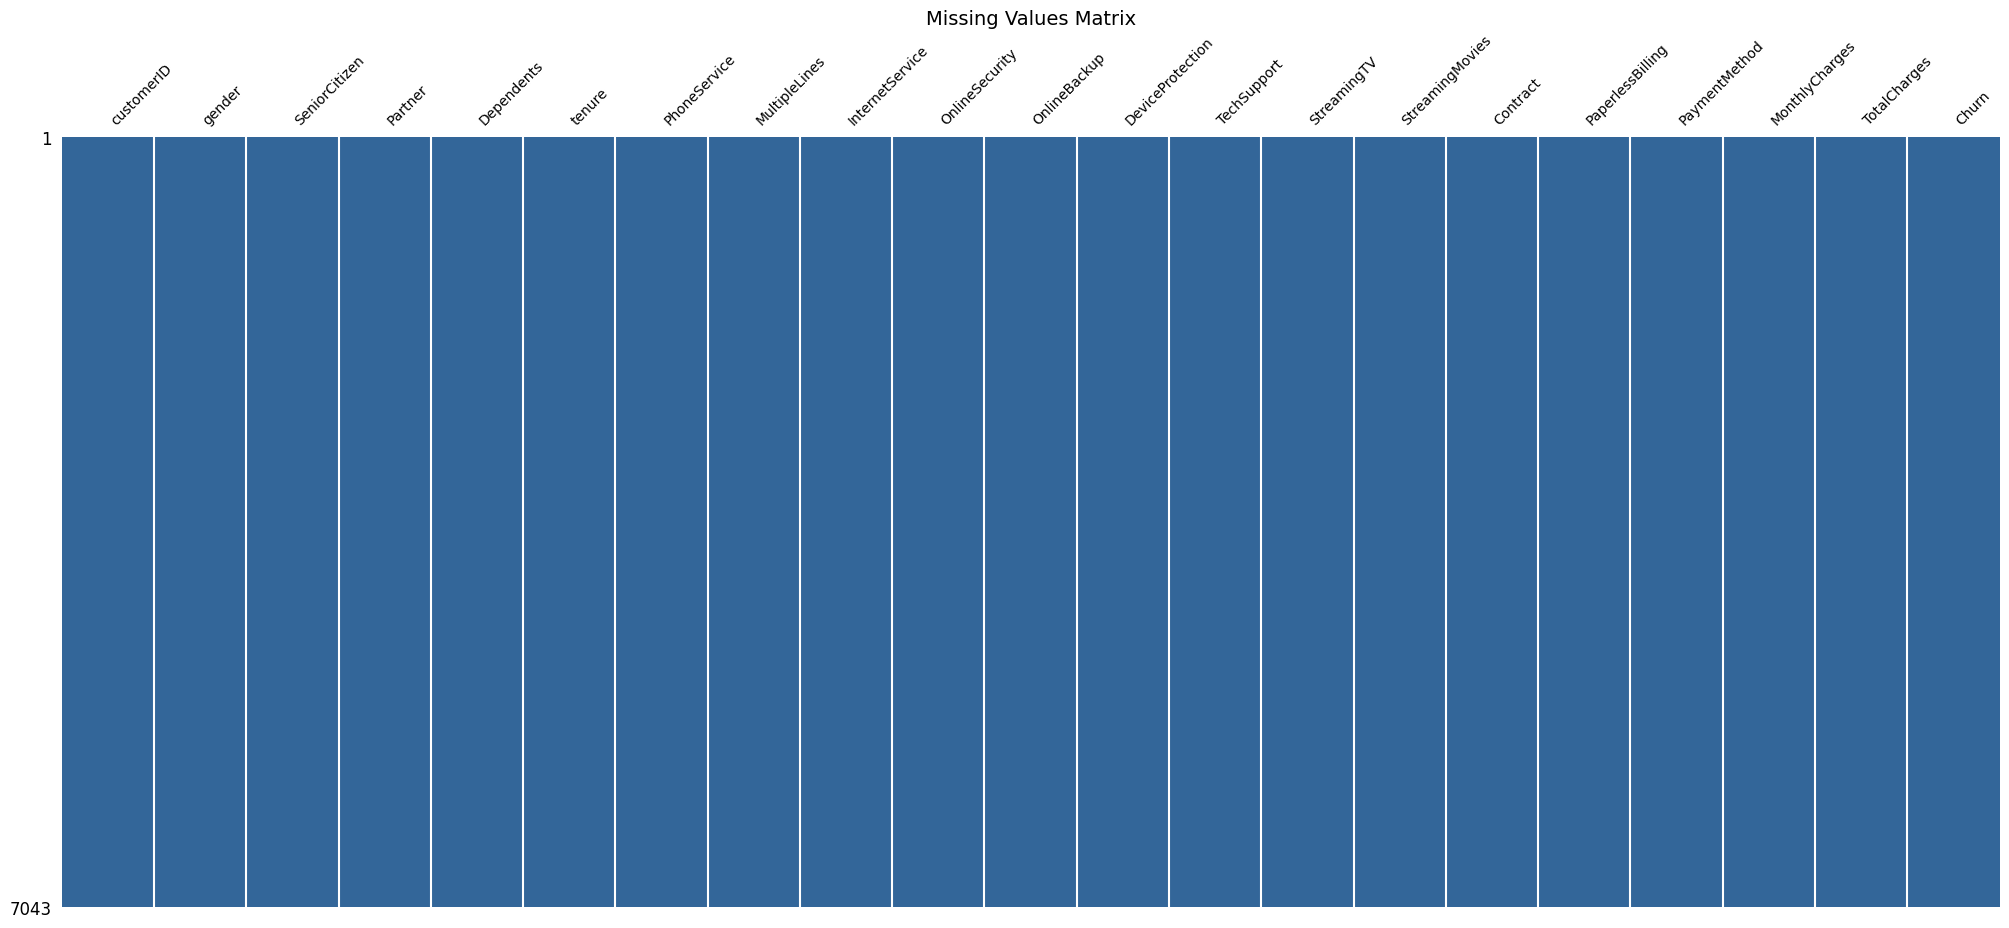

In [ ]:
plt.figure(figsize=(12,6))

msno.matrix(
    df,
    color=(0.2, 0.4, 0.6),
    fontsize=10,
    sparkline=False
)

plt.title('Missing Values Matrix', fontsize=14)
plt.show()

As shown in the matrix, the dataset does not appear to contain missing values. However, it is important to remember that missing data is not always stored in a format that Pandas can automatically recognize. In some cases, values such as `0`, blank spaces, or other invalid characters may also represent missing information and should be identified during the data cleaning process.

In [ ]:
# Remove the customerID column since it is not useful for the analysis

df = df.drop(columns=['customerID'])

# Convert TotalCharges to numeric format and turn invalid values into NaN

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


Based on the output above, the `TotalCharges` column contains 11 missing values. Let's inspect the rows associated with these missing values.

In [ ]:
df[np.isnan(df['TotalCharges'])]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


It can also be observed that the `tenure` column has a value of `0` for these entries, even though the `MonthlyCharges` column contains valid values. Let's check whether there are other records with `0` values in the `tenure` column.

In [ ]:
df[df['tenure'] == 0].index

Index([488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], dtype='int64')

There are no additional missing values associated with the `tenure` column. Since the dataset only contains 11 rows with missing values, removing them is a reasonable approach and is unlikely to have a significant impact on the overall analysis.

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.TotalCharges.min()

18.8

We can also confirm that there are no other customers with `0` values in the `TotalCharges` column.

Finally, let's transform the `SeniorCitizen` column into `Yes` and `No` categories to maintain consistency across the dataset.

In [ ]:
df["SeniorCitizen"]= df["SeniorCitizen"].map({0: "No", 1: "Yes"})
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# <span style="font-family:serif; font-size:28px;">5. Data Visualization</span>

#### Demographics

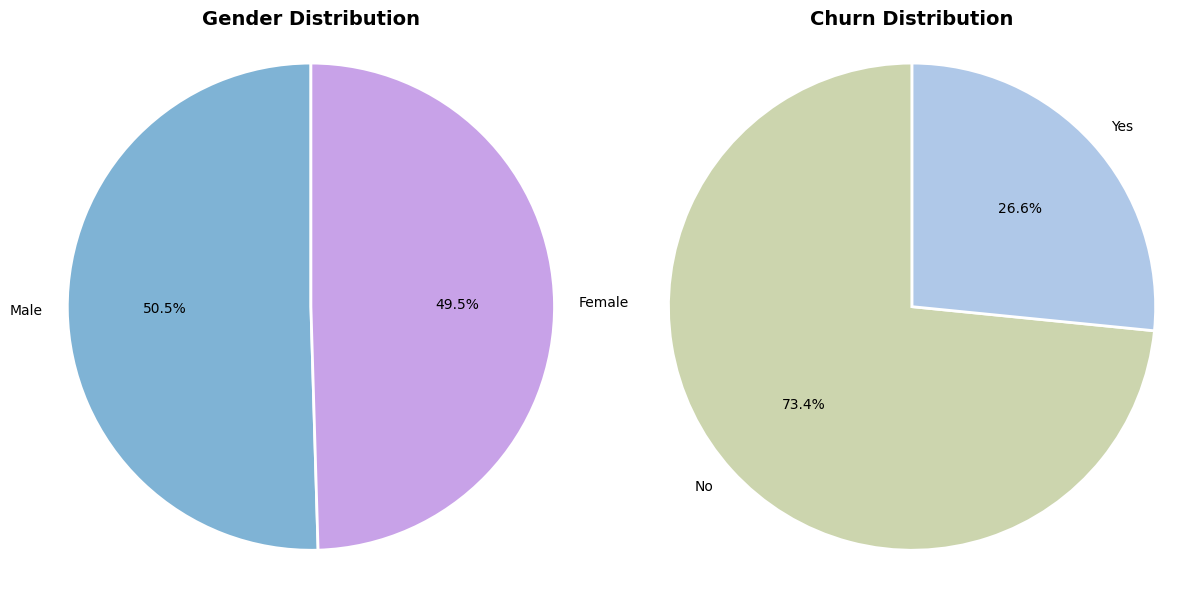

In [ ]:
gender_distribution = df['gender'].value_counts(normalize=True)
churned_customers =df['Churn'].value_counts(normalize=True)

fig, ax = plt.subplots(1, 2, figsize=(12,6))

ax[0].pie(
    gender_distribution,
    labels=gender_distribution.index,
    autopct='%1.1f%%',
    colors=['#7FB3D5', '#C8A2E8'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

ax[0].set_title('Gender Distribution', fontsize=14, fontweight='bold')
ax[0].axis('equal')

ax[1].pie(
    churned_customers,
    labels=churned_customers.index,
    autopct='%1.1f%%',
    colors=['#CCD5AE', '#AFC8E8'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

ax[1].set_title('Churn Distribution', fontsize=14, fontweight='bold')
ax[1].axis('equal')

plt.tight_layout()

In [ ]:
fig = px.sunburst(
    df,
    path=['Churn', 'gender'],
    color='Churn',
    color_discrete_map={
        'Yes': '#F2C6A0',
        'No': '#A8D5BA'
    },
    width=600,
    height=600,
    title='Customer Churn by Gender'
)

fig.update_traces(
    textinfo='label+percent entry'
)

fig.update_layout(
    margin=dict(t=50, l=0, r=0, b=0)
)

fig.show()

- Approximately 26.6% of customers discontinued the service and switched to another provider.
- The customer base is evenly distributed by gender, consisting of 49.5% female customers and 50.5% male customers.
- There is only a minimal difference in the percentage of customers who switched service providers between genders. Both male and female customers showed very similar churn behavior.

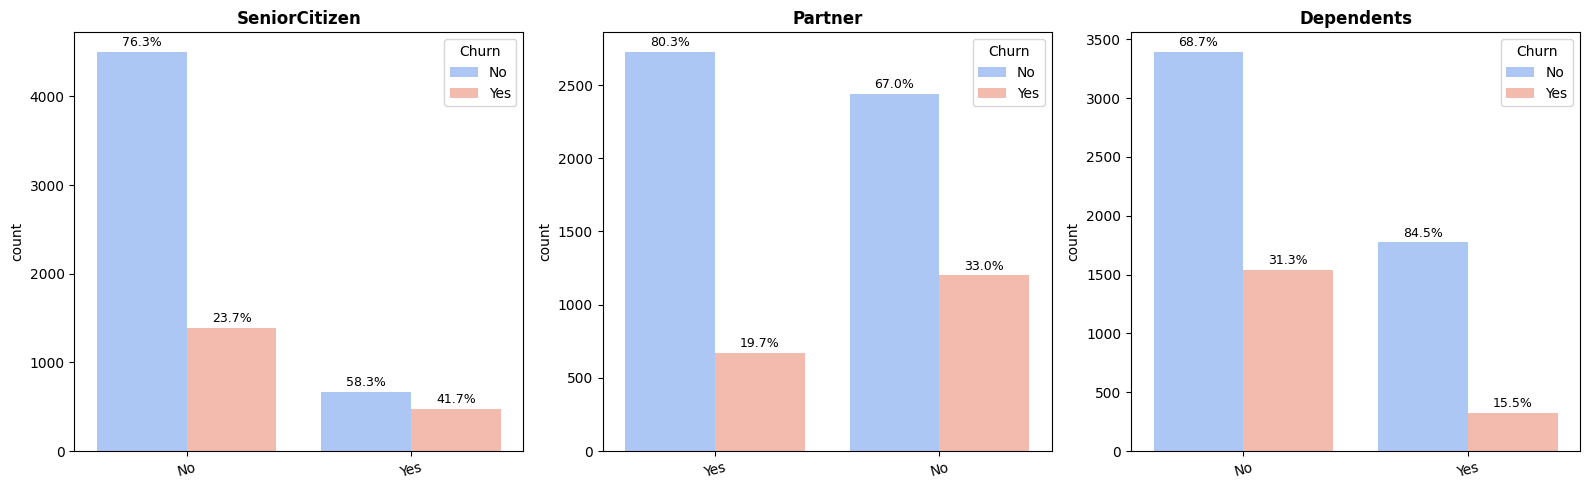

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(16,5))

ax = ax.flatten()

demographics = ['SeniorCitizen', 'Partner', 'Dependents']

df_plot = df.copy()

if df_plot['SeniorCitizen'].dtype != 'object':

    df_plot['SeniorCitizen'] = df_plot['SeniorCitizen'].map({
        0: 'No',
        1: 'Yes'
    })

for i, column in enumerate(demographics):

    sns.countplot(
        data=df_plot,
        x=column,
        hue='Churn',
        palette=['#A0C4FF', '#FFB4A2'],
        ax=ax[i]
    )

    ax[i].set_title(column, fontsize=12, fontweight='bold')
    ax[i].set_xlabel('')
    ax[i].tick_params(axis='x', rotation=15)

    category_totals = df_plot[column].value_counts()

    for container in ax[i].containers:

        labels = []

        for bar in container:

            height = bar.get_height()

            x_center = bar.get_x() + bar.get_width()/2

            x_index = round(x_center)

            category_name = ax[i].get_xticklabels()[x_index].get_text()

            total = category_totals[category_name]

            percentage = (height / total) * 100

            labels.append(f'{percentage:.1f}%')

        ax[i].bar_label(
            container,
            labels=labels,
            padding=2,
            fontsize=9
        )

plt.tight_layout()
plt.show()

### Senior Citizens
Senior citizens appear more likely to churn compared to non-senior customers. This may indicate greater sensitivity to pricing, customer support quality, or service reliability among older customers.

### Partner
Customers without a partner show a higher churn rate than customers with a partner. Customers in shared households may be less likely to switch providers due to shared expenses or bundled service usage.

### Dependents
Customers without dependents are also more likely to churn. In contrast, customers with dependents may place greater importance on maintaining stable communication and internet services, leading to higher retention.

### Services

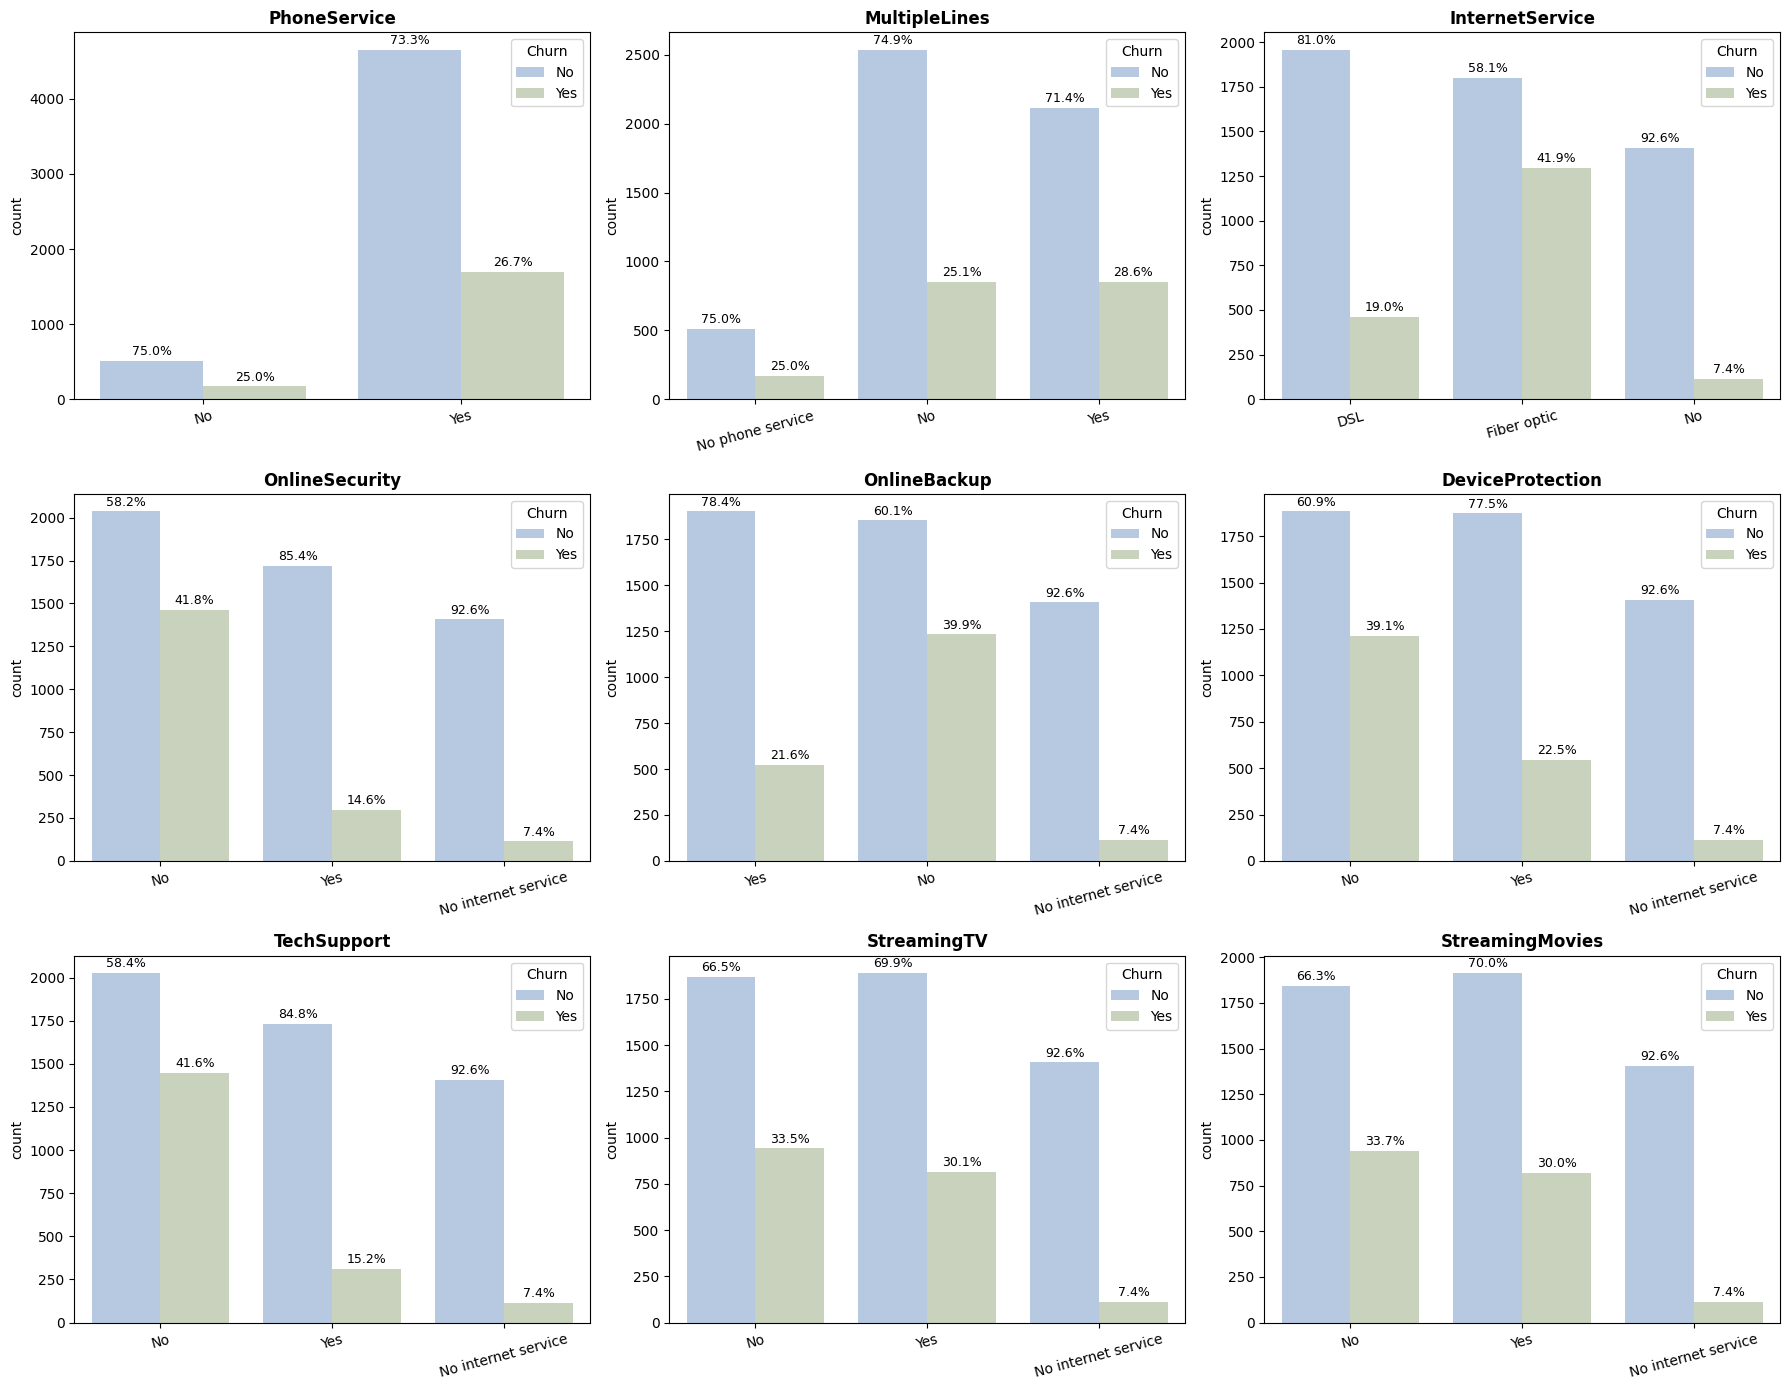

In [ ]:
services = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

fig, ax = plt.subplots(3, 3, figsize=(18, 14))

ax = ax.flatten()

for i, service in enumerate(services):

    sns.countplot(
        data=df,
        x=service,
        hue='Churn',
        palette=['#AFC8E8', '#C8D5B9'],
        ax=ax[i]
    )

    ax[i].set_title(service, fontsize=12, fontweight='bold')
    ax[i].set_xlabel('')
    ax[i].tick_params(axis='x', rotation=15)

    category_totals = df[service].value_counts()

    for container in ax[i].containers:

        labels = []

        for bar in container:

            category = bar.get_x() + bar.get_width()/2

            height = bar.get_height()

            x_index = round(category)

            category_name = ax[i].get_xticklabels()[x_index].get_text()

            total = category_totals[category_name]

            percentage = (height / total) * 100

            labels.append(f'{percentage:.1f}%')

        ax[i].bar_label(container, labels=labels, padding=2, fontsize=9)

plt.tight_layout()
plt.show()

### Phone Service
The churn rate is very similar for customers with and without phone service, so this feature does not seem to be a strong driver of retention on its own.

### Multiple Lines
Customers with multiple lines show a slightly higher churn rate than customers with a single line. This may suggest that the added cost or complexity of the service does not translate into enough value for some users.

### Internet Service
Fiber optic customers are more likely to churn than DSL customers. This could point to a pricing issue, stronger expectations for high-speed service, or dissatisfaction with the overall experience despite the premium technology.

### Online Security, Online Backup, Device Protection, and Tech Support
Customers with these services are less likely to churn, which suggests that support and protection features may strengthen loyalty. These services may increase perceived value and make the overall plan harder to leave or replace.

### Streaming TV and Streaming Movies
The difference is smaller here, but customers with streaming services still appear slightly less likely to churn. This may indicate that entertainment add-ons help keep customers engaged, even if they are not the main reason they stay.

### Account Information

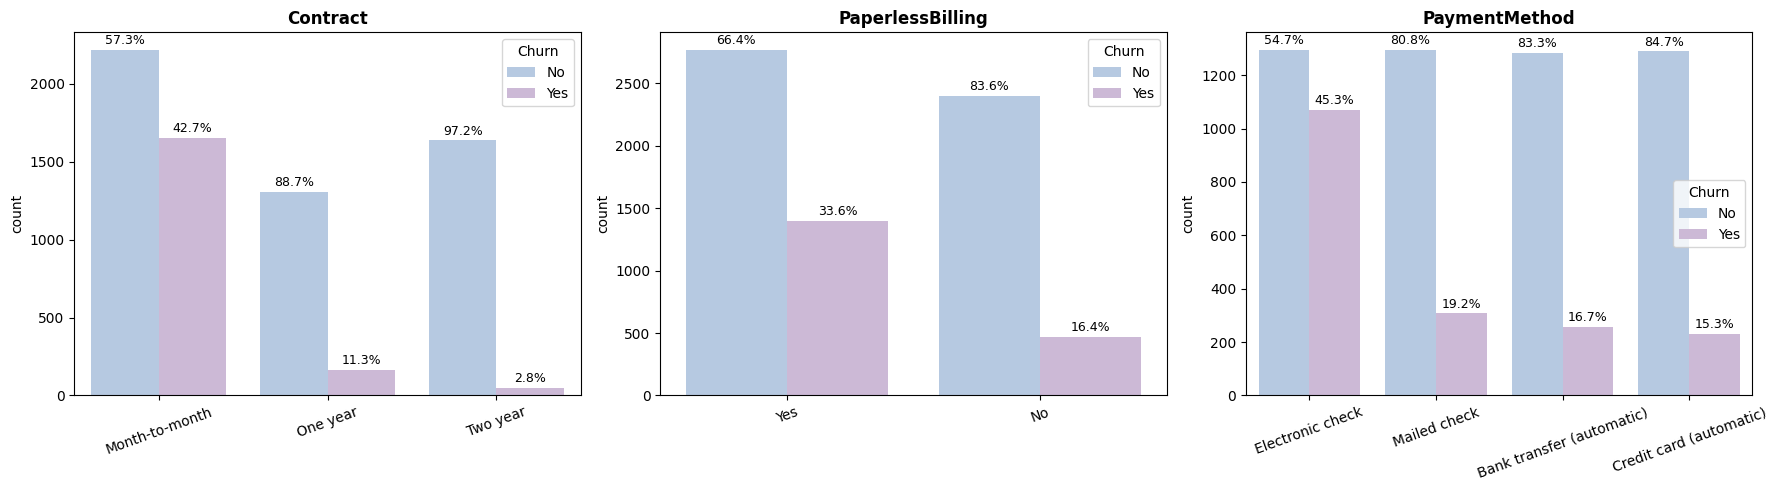

In [ ]:
account_details = ['Contract', 'PaperlessBilling', 'PaymentMethod']

fig, ax = plt.subplots(1, 3, figsize=(18,5))

ax = ax.flatten()

for i, detail in enumerate(account_details):

    sns.countplot(
        data=df,
        x=detail,
        hue='Churn',
        palette=['#AFC8E8', '#CDB4DB'],
        ax=ax[i]
    )

    ax[i].set_title(detail, fontsize=12, fontweight='bold')
    ax[i].set_xlabel('')
    ax[i].tick_params(axis='x', rotation=20)

    category_totals = df[detail].value_counts()

    for container in ax[i].containers:

        labels = []

        for bar in container:

            height = bar.get_height()

            x_center = bar.get_x() + bar.get_width() / 2

            x_index = round(x_center)

            category_name = ax[i].get_xticklabels()[x_index].get_text()

            total = category_totals[category_name]

            percentage = (height / total) * 100

            labels.append(f'{percentage:.1f}%')

        ax[i].bar_label(
            container,
            labels=labels,
            padding=2,
            fontsize=9
        )

plt.tight_layout()

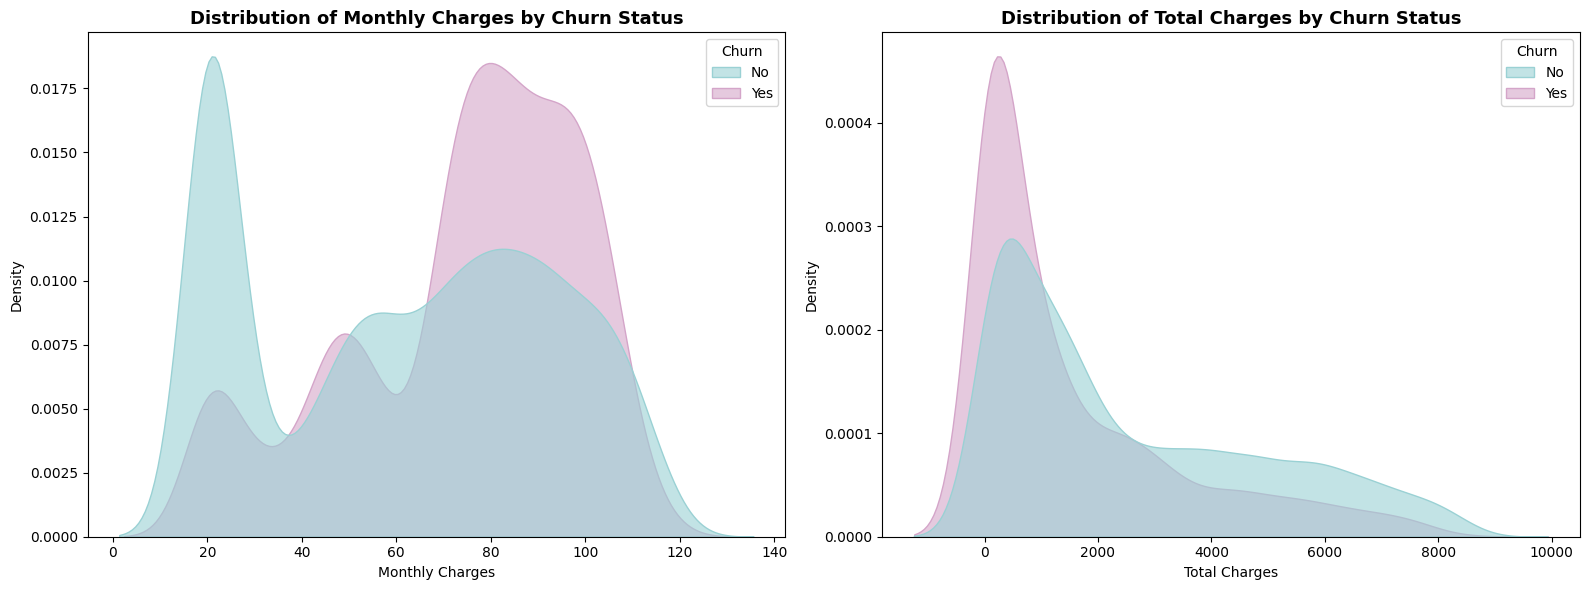

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16,6))

sns.kdeplot(
    data=df,
    x='MonthlyCharges',
    hue='Churn',
    fill=True,
    common_norm=False,
    palette=['#9AD1D4', '#D4A5C9'],
    alpha=0.6,
    ax=ax[0]
)

ax[0].set_title(
    'Distribution of Monthly Charges by Churn Status',
    fontsize=13,
    fontweight='bold'
)

ax[0].set_xlabel('Monthly Charges')
ax[0].set_ylabel('Density')

sns.kdeplot(
    data=df,
    x='TotalCharges',
    hue='Churn',
    fill=True,
    common_norm=False,
    palette=['#9AD1D4', '#D4A5C9'],
    alpha=0.6,
    ax=ax[1]
)

ax[1].set_title(
    'Distribution of Total Charges by Churn Status',
    fontsize=13,
    fontweight='bold'
)

ax[1].set_xlabel('Total Charges')
ax[1].set_ylabel('Density')

plt.tight_layout()
plt.show()

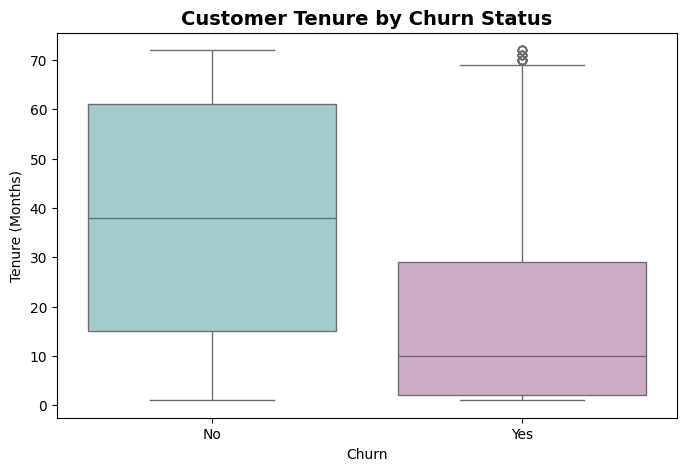

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Churn',
    y='tenure',
    hue='Churn',
    legend=False,
    palette=['#9AD1D4', '#D4A5C9']
)

plt.title(
    'Customer Tenure by Churn Status',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')

plt.show()

### Contract
There appears to be a strong relationship between contract length and customer retention. Customers with longer contracts are significantly less likely to churn, which is expected since long-term agreements increase customer commitment and reduce switching flexibility.

### Paperless Billing
Customers using paperless billing show a noticeably higher churn rate compared to customers who do not use paperless billing (33.6% vs 16.4%). This could indicate that paperless billing is more common among younger or more digitally active customers, who may also be more likely to switch providers.

### Payment Method
Customers who use electronic checks as their payment method are significantly more likely to churn than customers using other payment options. In contrast, customers enrolled in automatic bank transfers or credit card payments show lower and more stable churn rates. This may indicate that customers with automatic payment methods are more committed to the service, while electronic check users may have lower engagement or fewer barriers when switching providers.

### Monthly and Total Charges
Customers with higher monthly charges appear more likely to churn. This may indicate that pricing plays an important role in customer retention.

### Tenure
Customers with lower tenure are more likely to churn, indicating that newer customers are at a higher risk of leaving the company. This suggests that the first months of the customer lifecycle are especially important for retention efforts and customer satisfaction.

# <span style="font-family:serif; font-size:28px;">6. Data Preprocessing</span>

Before training the machine learning models, the dataset needs to be prepared through a preprocessing pipeline.

The features are first separated into categorical and numerical variables. The dataset is then divided into training and testing sets to evaluate model performance on unseen data.

To streamline preprocessing, separate pipelines are created for numerical and categorical features:

- Numerical variables are standardized using `StandardScaler` to normalize their scale.
- Categorical variables are transformed using `OneHotEncoder` to convert categories into numerical representations suitable for machine learning algorithms.

Finally, both pipelines are combined using a `ColumnTransformer`, allowing the appropriate transformations to be automatically applied to each feature type in a consistent and efficient workflow.

### Select Numerical and Categorical Variables

In [ ]:
numerical_variables = df.select_dtypes(include=np.number).columns

categorical_variables = (
    df.select_dtypes(include='object')
      .drop(columns=['Churn'])
      .columns
)

### Define Features and Target

In [ ]:
X = df[numerical_variables.union(categorical_variables)]

y = df['Churn']

In [ ]:
y = df['Churn'].map({
    'No': 0,
    'Yes': 1
})

### Split the Dataset

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Create Preprocessing Pipelines

In [ ]:
num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

### Combine Pipelines with ColumnTransformer

In [ ]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, numerical_variables),
    ('cat', cat_pipeline, categorical_variables)
])

# <span style="font-family:serif; font-size:28px;">7. Machine Learning Model Selection</span>

### Stratified K-Fold Cross Validation

Stratified K-Fold cross validation is used to compare several classification models while keeping the churn proportion consistent across folds. This helps avoid misleading results caused by uneven class splits.

In [ ]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

### Model Comparison

Logistic Regression, K-Nearest Neighbors, Support Vector Classifier, Random Forest, and XGBoost are evaluated using ROC-AUC. This metric is preferred because it measures how well each model separates churned from non-churned customers.

In [ ]:
models = {

    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    'K-Nearest Neighbors': KNeighborsClassifier(
        n_neighbors=5
    ),

    'Support Vector Classifier': SVC(
        kernel='rbf',
        probability=True,
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ),

    'XGBoost': XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        eval_metric='logloss'
    )
}

In [ ]:
for name, model in models.items():

  pipeline = Pipeline([
      ('preprocessor', preprocessor),
      ('model', model)
  ])

  scores = cross_val_score(
      pipeline,
      X_train,
      y_train,
      cv=skf,
      scoring='roc_auc',
      n_jobs=-1
  )

  print(f'{name}:')
  print(f'Mean ROC-AUC: {scores.mean():.4f}')
  print(f'Std: {scores.std():.4f}')
  print('-' * 40)

Logistic Regression:
Mean ROC-AUC: 0.8461
Std: 0.0052
----------------------------------------
K-Nearest Neighbors:
Mean ROC-AUC: 0.7821
Std: 0.0098
----------------------------------------
Support Vector Classifier:
Mean ROC-AUC: 0.8016
Std: 0.0134
----------------------------------------
Random Forest:
Mean ROC-AUC: 0.8444
Std: 0.0055
----------------------------------------
XGBoost:
Mean ROC-AUC: 0.8424
Std: 0.0049
----------------------------------------


Logistic Regression, Random Forest, and XGBoost deliver the strongest results, all with ROC-AUC scores around `0.85`. The fact that Logistic Regression performs almost as well as the more complex models suggests that the churn patterns in this dataset are fairly structured and can be captured well without overly complex algorithms.

### Hyperparameter Tuning

RandomizedSearchCV is then applied to Logistic Regression, Random Forest, and XGBoost to fine-tune the best-performing models. In the Logistic Regression search, the parameter space is small, so all possible combinations are explored.

In [ ]:
param_grids = {

    'Logistic Regression': {
        'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'model__penalty': ['l1', 'l2'],
        'model__solver': ['liblinear']
    },

    'Random Forest': {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [5, 10, 15, None],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4]
    },

    'XGBoost': {
        'model__n_estimators': [100, 200, 300],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__max_depth': [3, 5, 7],
        'model__subsample': [0.7, 0.8, 1.0],
        'model__colsample_bytree': [0.7, 0.8, 1.0]
    }
}

In [ ]:
best_models = {}

for name, model in models.items():

    if name not in param_grids:
        continue

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    random_search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_grids[name],
        n_iter=20,
        scoring='roc_auc',
        cv=skf,
        random_state=42,
        n_jobs=-1
    )

    random_search.fit(X_train, y_train)

    best_models[name] = random_search.best_estimator_

    print(f'{name}')
    print(f'Best ROC-AUC: {random_search.best_score_:.4f}')
    print(f'Best Params: {random_search.best_params_}')
    print('-' * 50)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning:

The total space of parameters 12 is smaller than n_iter=20. Running 12 iterations. For exhaustive searches, use GridSearchCV.



Logistic Regression
Best ROC-AUC: 0.8463
Best Params: {'model__solver': 'liblinear', 'model__penalty': 'l2', 'model__C': 10}
--------------------------------------------------
Random Forest
Best ROC-AUC: 0.8471
Best Params: {'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_depth': 10}
--------------------------------------------------
XGBoost
Best ROC-AUC: 0.8500
Best Params: {'model__subsample': 0.7, 'model__n_estimators': 300, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7}
--------------------------------------------------


After tuning, XGBoost achieves the highest ROC-AUC score, followed closely by Random Forest and Logistic Regression. Even so, the differences between the three models remain very small, which reinforces the idea that this dataset already contains strong predictive signals and does not require a highly complex model to perform well.

### Final Model Selection

XGBoost is selected as the final model because it achieved the highest ROC-AUC score during hyperparameter tuning. Although the performance difference compared to Logistic Regression and Random Forest is relatively small, XGBoost provides the strongest overall predictive performance.

In [ ]:
best_model = Pipeline([
    ('preprocessor', preprocessor),

    ('model', XGBClassifier(
        subsample=0.7,
        n_estimators=300,
        max_depth=3,
        learning_rate=0.01,
        colsample_bytree=0.7,
        random_state=42,
        eval_metric='logloss'
    ))
])

In [ ]:
best_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'Inter...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.01,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

# <span style="font-family:serif; font-size:28px;">8. Model Evaluation and Predictions</span>

### Model Evaluation

The fitted model is evaluated on the test set using ROC-AUC, classification report metrics, and a confusion matrix.

The classification report provides additional insight into:
- Precision: how reliable churn predictions are
- Recall: how many actual churners are correctly identified
- F1-score: the balance between precision and recall

In [ ]:
y_pred = best_model.predict(X_test)

In [ ]:
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f'ROC-AUC Score: {roc_auc:.4f}')
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred))

ROC-AUC Score: 0.8388

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.91      0.87      1033
           1       0.66      0.46      0.54       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407



The confusion matrix helps visualize prediction outcomes by comparing actual and predicted classes.

Initial results show that the model performs strongly when identifying non-churned customers, while churn prediction remains more challenging. This behavior is common in churn datasets due to class imbalance, where non-churned customers represent the majority class.

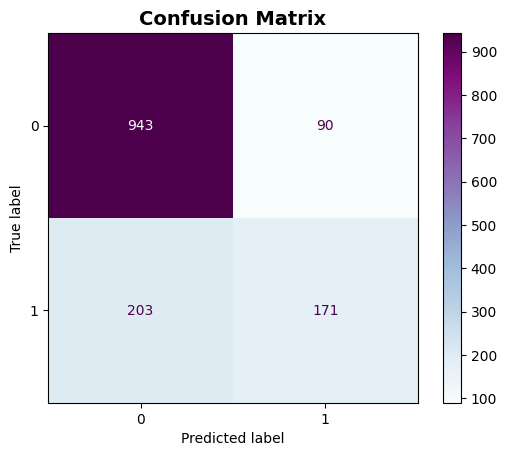

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap='BuPu',
    values_format='d'
)

plt.title(
    'Confusion Matrix',
    fontsize=14,
    fontweight='bold'
)

plt.show()

### Threshold Adjustment

The default classification threshold of `0.50` is then adjusted to `0.42` in order to improve churn detection performance.

Lowering the threshold allows the model to identify a larger proportion of customers at risk of churn. This is particularly important in churn prediction problems, where failing to identify potential churners may be more costly than generating additional false positives.

In [ ]:
threshold = 0.42

y_pred_custom = (
    y_pred_proba >= threshold
).astype(int)

print(f'Threshold: {threshold}')

print('\nClassification Report:\n')

print(
    classification_report(
        y_test,
        y_pred_custom
    )
)

Threshold: 0.42

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1033
           1       0.62      0.62      0.62       374

    accuracy                           0.80      1407
   macro avg       0.74      0.74      0.74      1407
weighted avg       0.80      0.80      0.80      1407



After adjusting the threshold, recall for churned customers improves significantly while precision remains relatively stable. This produces a more balanced model capable of detecting a higher proportion of churn-prone customers.

The updated confusion matrix also shows an improvement in churn classification performance, indicating that the adjusted threshold provides a better balance between identifying churners and limiting incorrect predictions.

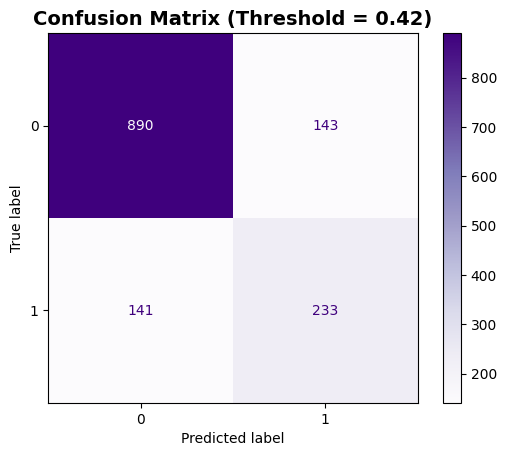

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_custom,
    cmap='Purples',
    values_format='d'
)

plt.title(
    'Confusion Matrix (Threshold = 0.42)',
    fontsize=14,
    fontweight='bold'
)

plt.show()

### ROC Curve

The ROC curve shows how well the model separates churned from non-churned customers across different classification thresholds. The curve remaining close to the upper-left corner indicates strong classification performance, which is consistent with the high ROC-AUC score obtained during evaluation.

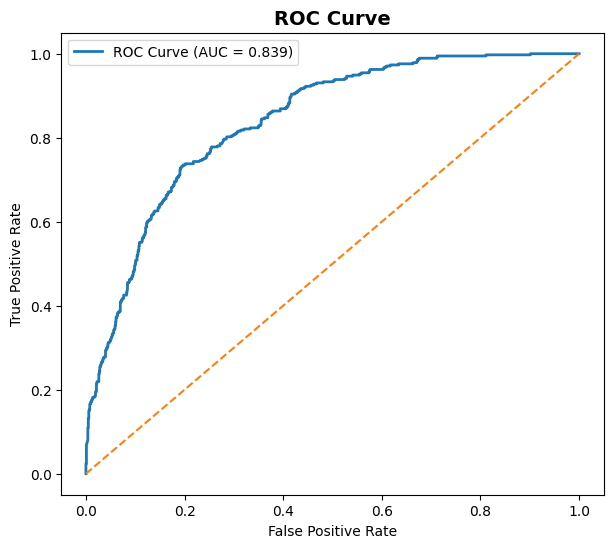

In [ ]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_pred_proba
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f'ROC Curve (AUC = {roc_auc:.3f})',
    linewidth=2
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title(
    'ROC Curve',
    fontsize=14,
    fontweight='bold'
)

plt.legend()

plt.show()

### Precision-Recall Curve

The Precision-Recall curve highlights the tradeoff between identifying more churners and maintaining reliable churn predictions. The curve suggests that the model is capable of improving churn detection while preserving a reasonable level of precision, which is especially important for customer retention strategies.

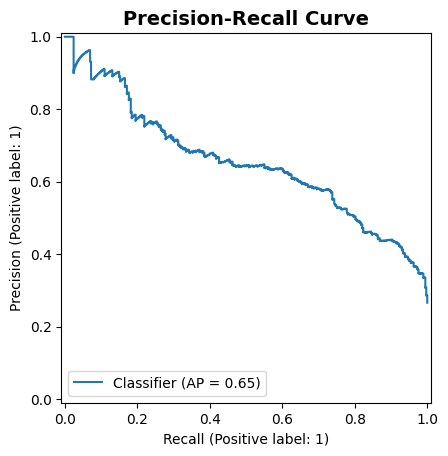

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_pred_proba
)

plt.title(
    'Precision-Recall Curve',
    fontsize=14,
    fontweight='bold'
)

plt.show()

### Feature Importance

Feature importance analysis helps identify which variables contribute most strongly to churn prediction. The results show that customer contract type, internet-related services, and customer tenure are among the most influential factors.

Customers with month-to-month contracts appear significantly more likely to churn, likely because they have lower long-term commitment. Similarly, customers without online security or tech support services may perceive lower overall service value or engagement.

Fiber optic internet also shows strong importance, which may indicate differences in customer expectations, pricing, or service experience. Finally, tenure remains one of the strongest predictors, reinforcing the idea that newer customers are more likely to churn than long-term customers.

/tmp/ipykernel_3451/3374386384.py:24: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




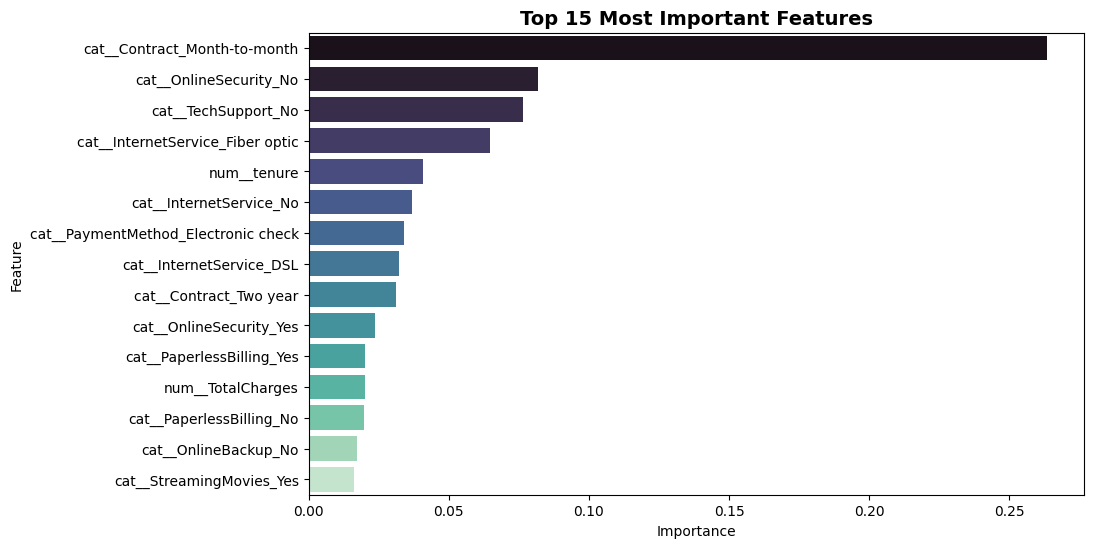

In [ ]:
feature_names = (
    best_model.named_steps['preprocessor']
    .get_feature_names_out()
)

importances = (
    best_model.named_steps['model']
    .feature_importances_
)

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance = (
    feature_importance
    .sort_values(by='Importance', ascending=False)
    .head(15)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature',
    palette='mako'
)

plt.title(
    'Top 15 Most Important Features',
    fontsize=14,
    fontweight='bold'
)

plt.show()

# <span style="font-family:serif; font-size:28px;">9. Further Business Implications</span>

- Customers with month-to-month contracts show significantly higher churn rates, suggesting that lower commitment plans increase customer mobility. Retention strategies could include loyalty discounts, bundled services, or incentives for transitioning to longer-term contracts.

- Fiber optic customers appear more likely to churn despite having access to newer technology. This may indicate higher customer expectations regarding speed, stability, pricing, or service quality. Improving technical support and customer experience for these users could help reduce churn.

- Customers without online security and tech support services are more likely to churn. These services may strengthen customer engagement by increasing perceived value and dependency on the platform. Promoting these features more actively or integrating them into service bundles may improve retention.

- Tenure remains one of the strongest churn predictors, with newer customers showing substantially higher churn rates. This suggests that the first months of the customer lifecycle are especially critical. Personalized onboarding, early follow-ups, and proactive support may help improve long-term retention.

- Customers with higher monthly charges also tend to churn more frequently. This may reflect pricing sensitivity or dissatisfaction with the perceived value of the service. Reviewing pricing strategies and offering customized plans for high-value customers could help improve customer satisfaction and retention.

- Customers using electronic check payment methods show noticeably higher churn rates compared to customers using more automated payment methods. This may suggest lower customer engagement or a less stable long-term relationship with the service.